🔄 Step 1: Initializing RAGAS Evaluator Judgements...
📦 Step 2: Formulating System Simulation Matrices...
📊 Analyzing Chunk Size Strategy: 200_chars...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

📊 Analyzing Chunk Size Strategy: 500_chars...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

📊 Analyzing Chunk Size Strategy: 1000_chars...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


📈 Step 5: Generating Performance Curve Line Plots...


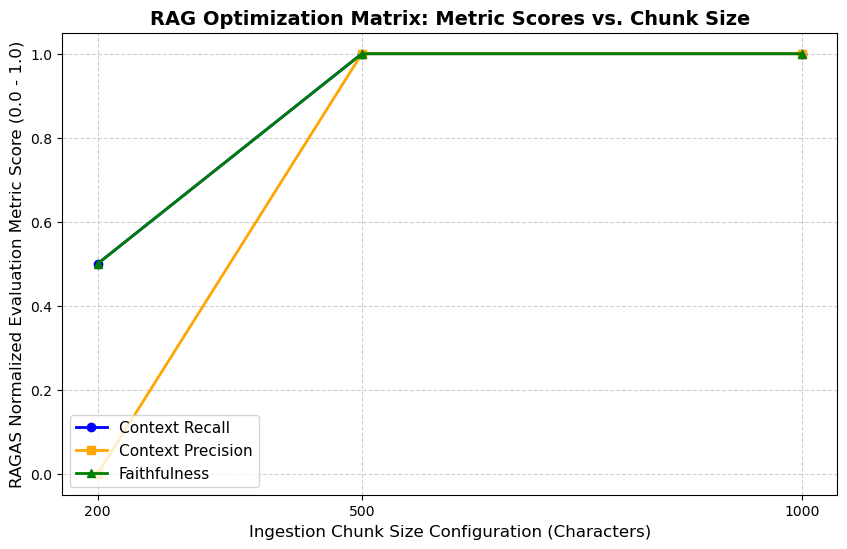

🏁 Visualization successfully generated, displayed, and saved as 'chunk_optimization_curve.png'!


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas import evaluate
from ragas.metrics import faithfulness, context_recall, context_precision

# 💡 This inline command ensures your plot renders directly inside your VS Code notebook window
%matplotlib inline

# 🔑 Set your API key if it's not already in your system environment variables
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = "<Enter your APIs>"

print("🔄 Step 1: Initializing RAGAS Evaluator Judgements...")
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o"))
evaluator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

# Master Baseline Question & Reference Ground Truth
user_query = "What is the policy regarding commercial racing and the absolute accident reporting timeline?"
reference_truth = "Our company premium insurance plan rejects any vehicle claims involving unauthorized commercial racing. All premium plan members must report any vehicular accident within 48 hours to preserve eligibility for complete coverage."

print("📦 Step 2: Formulating System Simulation Matrices...")
simulated_runs = {
    "200_chars": {
        "user_input": [user_query],
        "contexts": [["Our company premium insurance plan rejects any vehicle claims involving unauthorized commercial racing."]], 
        "response": ["Claims involving commercial racing are rejected by the premium plan. I couldn't find a deadline."],
        "reference": [reference_truth]
    },
    "500_chars": {
        "user_input": [user_query],
        "contexts": [["Our company premium insurance plan rejects any vehicle claims involving unauthorized commercial racing. All premium plan members must report any vehicular accident within 48 hours to preserve eligibility for complete coverage."]], 
        "response": ["Commercial racing claims are rejected, and you must report any accident within 48 hours to retain complete coverage."],
        "reference": [reference_truth]
    },
    "1000_chars": {
        "user_input": [user_query],
        "contexts": [["Our company premium insurance plan rejects any vehicle claims involving unauthorized commercial racing. All premium plan members must report any vehicular accident within 48 hours to preserve eligibility for complete coverage. In unrelated updates, cafeteria lunch hour benefits have changed to 45 minutes max, steel-toed boots must be worn at all operational facilities, and parking pass renewals are due on the first day of every subsequent fiscal quarter."]], 
        "response": ["Commercial racing is excluded, accidents must be reported within 48 hours, and remember that your parking passes are due on the first day of the quarter."], 
        "reference": [reference_truth]
    }
}

chunk_sizes = [200, 500, 1000]
faithfulness_scores = []
recall_scores = []
precision_scores = []

# Loop through and calculate metrics for each specific strategy run
for size in ["200_chars", "500_chars", "1000_chars"]:
    print(f"📊 Analyzing Chunk Size Strategy: {size}...")
    dataset = Dataset.from_dict(simulated_runs[size])
    
    report = evaluate(
        dataset=dataset,
        metrics=[faithfulness, context_recall, context_precision],
        llm=evaluator_llm,
        embeddings=evaluator_embeddings
    )
    
    df = report.to_pandas()
    faithfulness_scores.append(df['faithfulness'].values[0])
    recall_scores.append(df['context_recall'].values[0])
    precision_scores.append(df['context_precision'].values[0])

print("\n📈 Step 5: Generating Performance Curve Line Plots...")
plt.figure(figsize=(10, 6))
plt.plot(chunk_sizes, recall_scores, label='Context Recall', marker='o', color='blue', linewidth=2)
plt.plot(chunk_sizes, precision_scores, label='Context Precision', marker='s', color='orange', linewidth=2)
plt.plot(chunk_sizes, faithfulness_scores, label='Faithfulness', marker='^', color='green', linewidth=2)

plt.title('RAG Optimization Matrix: Metric Scores vs. Chunk Size', fontsize=14, fontweight='bold')
plt.xlabel('Ingestion Chunk Size Configuration (Characters)', fontsize=12)
plt.ylabel('RAGAS Normalized Evaluation Metric Score (0.0 - 1.0)', fontsize=12)
plt.xticks(chunk_sizes)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower left')

# Save the final chart image locally and display it
plt.savefig('chunk_optimization_curve.png', dpi=300, bbox_inches='tight')
plt.show() 
print("🏁 Visualization successfully generated, displayed, and saved as 'chunk_optimization_curve.png'!")